# 01 - Percentile Interval Extraction - DEMO VERSION

## Input Data
- **Daily NetCDF files** from WRF simulations (15-min temporal resolution), AFWA_TOTPRECIP
  - **DEMO**: Uses spatially subset data (50×50 grid cells) with "_demo.nc" suffix
- **Historical percentiles dataset** (wet periods > 0.254 mm trace threshold)
  - **DEMO**: Pre-calculated percentiles for demo spatial subset
- Spatial: Regional subset (50×50 grid cells)
- Temporal: 2 water years (Oct 1990 - Sep 1992)
- Scenarios: HIST only (demo uses historical period)

## Processing Steps
1. **Define precipitation bands (intervals)**:
   - **0–0.254 mm** (sub-trace precipitation, also serves as quick sanity QC check)
   - **>0.254 mm**: Percentile-based bands (e.g., trace-10th, 10th-20th, ..., 80th-90th, 90th–99th)
   - Percentiles calculated only from wet periods above 0.254mm
   
2. **Filter by season** (or annual, defined by months):
   - All months or seasonal subset
   - Applied lazily using Dask
   
3. **Calculate for each band**:
   - **Occurrences**: Count of 15-min periods within band
   - **Accumulations**: Total precipitation (mm) within band
   
4. **Aggregate spatially**:
   - Per grid cell across water year
   - Sub-trace band (0mm-0.254mm) provides consistency check on precipitation frequency

## Output
- **Two NetCDF file types** per band/year/season:
  - `DIST_*`: Occurrence counts (`PRECIP_PERIOD`, 15-minute period count)
  - `Accum_*`: Precipitation sums (`PRECIP_SUM`, mm)
- Output location: `./output/demo/HIST/`
- Used to quantify contribution of different intensity ranges to total precipitation

## Demo Notes
- This notebook uses a spatial subset (50×50 grid cells) and 2 years of data
- File structure is simplified compared to full WRF-BCC dataset
- Results will differ from full domain due to limited spatial/temporal extent
- **Purpose**: Method verification and code testing on laptop-scale resources
- **Runtime**: ~30-60 minutes on laptop (vs ~1 week for full domain)




In [1]:

# DEMO: Percentile Interval Extraction

# This demo uses a spatial/temporal subset (50×50 grid, 2 years) for testing
# 
# Expected directory structure (notebook at root of archive):
#   ./data/demo/precipitation/     - Demo WRF output files
#   ./data/demo/percentiles/       - Pre-calculated percentiles
#   ./data/demo/geo_em_d01_demo.nc - Demo grid file
#   ./output/demo/                 - Results saved here (created automatically)
#
# No path configuration needed - all paths are relative to notebook location assuming this notebook is run from the SDHI root dir


In [2]:
# Import Libraries
from __future__ import annotations

# OS packages
import os
import itertools
import glob
import time
import gc

# Data Packages
import numpy as np
import dask.array as da
import xarray as xr

# Plotting Packages
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.offsetbox import AnchoredText
from matplotlib import gridspec, colors, cm, ticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LATITUDE_FORMATTER, LONGITUDE_FORMATTER
import cartopy.io.img_tiles as cimgt
from datetime import datetime, timedelta

# MPL inline magic
%matplotlib inline



In [3]:
# Set up Dask Environment
from distributed import Client

# DEMO: Reduced resources for laptop execution
# Adjust these values based on your laptop specifications
client = Client(n_workers=2, threads_per_worker=2, memory_limit="8GB")
client


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 2
Total threads: 4,Total memory: 14.90 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:36706,Workers: 2
Dashboard: http://127.0.0.1:8787/status,Total threads: 4
Started: Just now,Total memory: 14.90 GiB
Comm: tcp://127.0.0.1:46405,Total threads: 2
Dashboard: http://127.0.0.1:42716/status,Memory: 7.45 GiB
Nanny: tcp://127.0.0.1:42271,


In [4]:
# Helper Functions
def filter_valid_file_paths(file_paths):
    """Filter out file paths that don't exist."""
    valid_file_paths = []
    for path in file_paths:
        if os.path.exists(path):
            valid_file_paths.append(path)
    return valid_file_paths


def get_files_in_date_range(path, date_range, hours_offset):
    """
    Get demo files within a specified date range.
    
    DEMO VERSION: Simplified file structure.
    Demo files are named: AFWA_TOTPRECIP_YYYY-MM-DD_demo.nc
    All in single directory (no year subdirectories).
    """
    date_format = "%Y-%m-%d"
    
    # Parse the date range string
    start_date_str, end_date_str = date_range.split(" to ")
    start_date = datetime.strptime(start_date_str, date_format)
    end_date = datetime.strptime(end_date_str, date_format)
    
    # Apply the offset
    hours_offset += 24
    offset_timedelta = timedelta(hours=hours_offset)
    end_date += offset_timedelta
    
    # Initialize the list of files
    files = []
    
    # Iterate over each date in the date range
    current_date = start_date
    while current_date <= end_date:
        year = current_date.year
        month = current_date.month
        day = current_date.day
        
        # DEMO: Simplified path structure - all files in same directory
        fpath = f"{path}/AFWA_TOTPRECIP_{year}-{month:02d}-{day:02d}_demo.nc"
        
        # Add file path to list
        files.extend([fpath])
        
        # Increment the current date by 1 day
        current_date += timedelta(days=1)
        
    return filter_valid_file_paths(files)


In [5]:
# Configuration - Demo Data Paths

# DEMO VERSION: Only historical scenario with limited years (the demo data extent)
scenario = "HIST"

# DEMO: Limited year range (2 years for demonstration)
# Note: These are water years (Oct 1 - Sep 30)
years = list(range(1990, 1992, 1))  # 1990-1991 and 1991-1992 water years

print(f"DEMO MODE - Selected scenario: {scenario}")
print(f"DEMO MODE - Year range: {years[0]}-{years[-1]+1}")
print(f"Note: This is a spatial/temporal subset for demonstration purposes")
print(f"      Full analysis uses 15 water years per scenario")

# Seasons to process
run_seasons = [[[3,4,5],       # Spring
                [6,7,8],       # Summer
                [9,10,11],     # Fall
                [12,1,2],      # Winter
                [1,2,3,4,5,6,7,8,9,10,11,12]     #Annual
               ]]


hours_offset = -1

DEMO MODE - Selected scenario: HIST
DEMO MODE - Year range: 1990-1992
Note: This is a spatial/temporal subset for demonstration purposes
      Full analysis uses 15 water years per scenario


In [6]:
# Define Percentile Bands

# Define the percentile bands to process
# Format: (lower_bound, upper_bound, is_lower_fixed, is_upper_fixed)

percentile_bands = [
    # 0mm to <0.254mm (sub-trace)
    (0.0, 0.254, True, True),
    
    # 0.254mm to <10th percentile (light rain)
    (0.254, 0.10, True, False),
    
    # 10th percentile bands (moderate rain)
    (0.10, 0.20, False, False),
    (0.20, 0.30, False, False),
    (0.30, 0.40, False, False),
    (0.40, 0.50, False, False),
    (0.50, 0.60, False, False),
    (0.60, 0.70, False, False),
    (0.70, 0.80, False, False),
    (0.80, 0.90, False, False),
    
    # 90th to 99th band (heavy rain)
    (0.90, 0.99, False, False),
    
    # ≥99th percentile (extreme rain)
    (0.99, 10000, False, True)
]

# Display configuration
print("Processing plan:")
print(f"Scenario: {scenario}")
print(f"Years: {years[0]}-{years[-1]+1}")

# Format and display the percentile bands
print("\nPercentile bands to process:")
for i, band in enumerate(percentile_bands):
    lower, upper, is_lower_fixed, is_upper_fixed = band
    
    # Format the band description
    if is_lower_fixed:
        lower_desc = f"{lower:.3f}mm".replace(".", "p")
    else:
        lower_desc = f"p{int(lower*100)}"
        
    if is_upper_fixed:
        if upper >= 1000:
            upper_desc = "99thplus"
        else:
            upper_desc = f"{upper:.3f}mm".replace(".", "p")
    else:
        upper_desc = f"p{int(upper*100)}"
        
    print(f"{i+1}. {lower_desc} to {upper_desc}")

# Print season information
print("\nSeasons to process:")
for i, season_group in enumerate(run_seasons):
    for j, season in enumerate(season_group):
        season_name = "ALL" if len(season) == 12 else "".join(["JFMAMJJASOND"[m-1] for m in season])
        if len(season) < 12:
            season_desc = ""
            if set(season) == {3, 4, 5}:
                season_desc = " (Spring)"
            elif set(season) == {6, 7, 8}:
                season_desc = " (Summer)"
            elif set(season) == {9, 10, 11}:
                season_desc = " (Fall)"
            elif set(season) == {12, 1, 2}:
                season_desc = " (Winter)"
            print(f"  - {season_name}{season_desc}: months {season}")
        else:
            print(f"  - {season_name} (All months)")



Processing plan:
Scenario: HIST
Years: 1990-1992

Percentile bands to process:
1. 0p000mm to 0p254mm
2. 0p254mm to p10
3. p10 to p20
4. p20 to p30
5. p30 to p40
6. p40 to p50
7. p50 to p60
8. p60 to p70
9. p70 to p80
10. p80 to p90
11. p90 to p99
12. p99 to 99thplus

Seasons to process:
  - MAM (Spring): months [3, 4, 5]
  - JJA (Summer): months [6, 7, 8]
  - SON (Fall): months [9, 10, 11]
  - DJF (Winter): months [12, 1, 2]
  - ALL (All months)


In [7]:
# Main Processing Function
def percentiles_from_daily(run_season, yr_, lower_bound, upper_bound, is_lower_fixed=False, is_upper_fixed=False):
    """
    Process precipitation data for a given percentile or fixed mm band.
    
    DEMO VERSION: Uses demo data paths and simplified structure.
    
    Parameters:
    -----------
    run_season : list
        List of months to include (1-12)
    yr_ : int
        Starting year for the water year (Oct 1 to Sep 30)
    lower_bound : float
        Lower bound of the band (percentile between 0-1 or mm threshold)
    upper_bound : float
        Upper bound of the band (percentile between 0-1 or mm threshold)
    is_lower_fixed : bool
        If True, lower_bound is a fixed threshold in mm; if False, it's a percentile (0-1)
    is_upper_fixed : bool
        If True, upper_bound is a fixed threshold in mm; if False, it's a percentile (0-1)
    """
    # Get the start time for performance tracking
    st = time.time()
    
    # Define the date range for the water year
    hours_offset = -1
    date_start = f'{yr_}-10-01'
    date_end = f'{yr_+1}-09-30'
    year_range = f'{date_start[:4]}-{date_end[:4]}'
    print(f"Processing year range: {year_range}")
    
    # Create a string representation of months in the season
    months_dict = {1: "J", 2: "F", 3: "M", 4: "A", 5: "M", 6: "J", 
                   7: "J", 8: "A", 9: "S", 10: "O", 11: "N", 12: "D"}
    months_of_data_str = "".join([months_dict[v] for v in run_season]) if len(run_season) < 12 else "ALL"
    print(f"Months: {months_of_data_str}")
    
    # Format the band description for output filenames
    if is_lower_fixed:
        lower_desc = f"{lower_bound:.3f}mm".replace(".", "p")
    else:
        lower_desc = f"p{int(lower_bound*100)}" if lower_bound < 1 else f"p{int(lower_bound)}"
    
    if is_upper_fixed:
        if upper_bound >= 1000:
            upper_desc = "99thplus"
        else:
            upper_desc = f"{upper_bound:.3f}mm".replace(".", "p")
    else:
        upper_desc = f"p{int(upper_bound*100)}" if upper_bound < 1 else f"p{int(upper_bound)}"
    
    band_desc = f"{lower_desc}-{upper_desc}"
    print(f"Processing band: {band_desc}")
    
    # DEMO: Simplified data path - all demo files in one directory
    data_path = "./data/demo/precipitation"
    
    # Load daily precipitation dataset files
    files0 = get_files_in_date_range(data_path, f'{date_start} to {date_end}', hours_offset)
    files0.sort()
    print(f'Number of files in dataset: {len(files0)}')
    
    if len(files0) == 0:
        raise ValueError(f"No files found for date range {date_start} to {date_end}")
    
    # Only load percentiles dataset if needed for non-fixed thresholds
    percentile_file = None
    if not (is_lower_fixed and is_upper_fixed):
        # DEMO: Load pre-calculated percentiles for demo subset
        percentile_path = f'./data/demo/percentiles/historical_{months_of_data_str}_quantiles_gt0p254_demo.nc'
        print(f'Percentiles from: {percentile_path}')
        
        if os.path.exists(percentile_path):
            percentile_file = [percentile_path]
            print(f'Number of percentile files: {len(percentile_file)}')
        else:
            raise ValueError(f"Percentile file not found: {percentile_path}")
    
    # DEMO: Load the demo WRF grid (already spatially subset)
    grid = xr.open_dataset("./data/demo/geo_em_d01_demo.nc")
    
    # Load the daily precipitation data using Dask for delayed computation
    print("Loading precipitation data...")
    das0 = []
    for f in files0:
        da0 = xr.open_dataset(f, chunks='auto', engine='netcdf4')
        das0.append(da0)
    
    ds0 = xr.concat(das0, dim="Time")
    
    # Filter the data by season lazily
    if len(run_season) < 12:  # Only filter if not using all months
        ds0 = ds0.where(ds0.Time.dt.month.isin(run_season))
    
    # Prepare threshold values
    print("Preparing threshold values...")
    
    # Handle the different combinations of fixed vs percentile thresholds
    if is_lower_fixed and is_upper_fixed:
        # Both thresholds are fixed values in mm
        quantile_thresh_0 = lower_bound
        quantile_thresh_1 = upper_bound
        print(f"Using fixed thresholds: {quantile_thresh_0}mm to {quantile_thresh_1}mm")
    elif is_lower_fixed and not is_upper_fixed:
        # Lower is fixed mm, upper is percentile
        quantile_thresh_0 = lower_bound
        # Load percentile dataset
        ds1 = xr.open_dataset(percentile_file[0], chunks='auto', engine='netcdf4')
        quantile_thresh_1 = ds1.AFWA_TOTPRECIP.sel(quantile=upper_bound, method='nearest')
        print(f"Using fixed lower: {quantile_thresh_0}mm and percentile upper: {upper_bound}")
        ds1.close()
    elif not is_lower_fixed and is_upper_fixed:
        # Lower is percentile, upper is fixed mm
        ds1 = xr.open_dataset(percentile_file[0], chunks='auto', engine='netcdf4')
        quantile_thresh_0 = ds1.AFWA_TOTPRECIP.sel(quantile=lower_bound, method='nearest')
        quantile_thresh_1 = upper_bound
        print(f"Using percentile lower: {lower_bound} and fixed upper: {quantile_thresh_1}mm")
        ds1.close()
    else:
        # Both are percentiles
        ds1 = xr.open_dataset(percentile_file[0], chunks='auto', engine='netcdf4')
        quantile_thresh_0 = ds1.AFWA_TOTPRECIP.sel(quantile=lower_bound, method='nearest')
        quantile_thresh_1 = ds1.AFWA_TOTPRECIP.sel(quantile=upper_bound, method='nearest')
        print(f"Using percentile thresholds: {lower_bound} to {upper_bound}")
        ds1.close()
    
    # Create boolean masks for the band
    print("Creating masks for the precipitation band...")
    da_bool_period_0 = ds0.AFWA_TOTPRECIP >= quantile_thresh_0
    da_bool_period_1 = ds0.AFWA_TOTPRECIP < quantile_thresh_1
    da_bool_period = da_bool_period_0 & da_bool_period_1
    
    # Calculate occurrences (number of 15-min periods in the band)
    print("Calculating occurrences...")
    precip_occur = da_bool_period.sum(dim='Time', skipna=True)
    
    # Create occurrence dataset with metadata
    precip_occur.name = 'PRECIP_PERIOD'
    ds_occur = xr.Dataset({'PRECIP_PERIOD': precip_occur})
    
    # Add metadata
    ds_occur.attrs['lower_bound'] = str(lower_bound)
    ds_occur.attrs['upper_bound'] = str(upper_bound)
    ds_occur.attrs['is_lower_fixed'] = str(is_lower_fixed)
    ds_occur.attrs['is_upper_fixed'] = str(is_upper_fixed)
    ds_occur.attrs['band_description'] = band_desc
    ds_occur.attrs['months'] = str(run_season)
    ds_occur.attrs['precip_thresh_for_quantile_calc_mm'] = 0.254
    ds_occur.attrs['demo_note'] = 'Spatial subset (50x50 grid cells) for demonstration'
    
    # Calculate accumulations (sum of precipitation in the band)
    print("Calculating accumulations...")
    precip_masked = ds0.AFWA_TOTPRECIP.where(da_bool_period)
    precip_sum = precip_masked.sum(dim='Time', skipna=True)
    
    # Create accumulation dataset with metadata
    precip_sum.name = 'PRECIP_SUM'
    ds_accum = xr.Dataset({'PRECIP_SUM': precip_sum})
    
    # Add metadata
    ds_accum.attrs['lower_bound'] = str(lower_bound)
    ds_accum.attrs['upper_bound'] = str(upper_bound)
    ds_accum.attrs['is_lower_fixed'] = str(is_lower_fixed)
    ds_accum.attrs['is_upper_fixed'] = str(is_upper_fixed)
    ds_accum.attrs['band_description'] = band_desc
    ds_accum.attrs['months'] = str(run_season)
    ds_accum.attrs['precip_thresh_for_quantile_calc_mm'] = 0.254
    ds_accum.attrs['demo_note'] = 'Spatial subset (50x50 grid cells) for demonstration'
    
    # DEMO: Create output directory in demo structure (similar to full analysis)
    output_dir = f"./output/demo/{scenario}"
    os.makedirs(output_dir, exist_ok=True)
    
    # Save occurrence dataset (note: NO "_demo" suffix on output files)
    occur_filename = f"DIST_{scenario}_{year_range}_{months_of_data_str}_{band_desc}_0p254base_wet_period.nc"
    occur_path = os.path.join(output_dir, occur_filename)
    print(f"Saving occurrences to: {occur_path}")
    ds_occur.to_netcdf(path=occur_path, mode="w")
    
    # Save accumulation dataset
    accum_filename = f"Accum_{scenario}_{year_range}_{months_of_data_str}_{band_desc}_0p254base_wet_period.nc"
    accum_path = os.path.join(output_dir, accum_filename)
    print(f"Saving accumulations to: {accum_path}")
    ds_accum.to_netcdf(path=accum_path, mode="w")
    
    # Report processing time
    elapsed = time.time() - st
    print(f"Processing time: {elapsed:.2f} seconds ({elapsed/60:.2f} minutes)")
    print(f"Current time: {datetime.now().strftime('%H:%M:%S')}")
    print("-" * 50)
    
    # Clean up to release memory
    ds0.close()
    grid.close()
    gc.collect()

In [8]:
# Optional - Visualize Results
def visualize_band_results(year, band_desc, var_type='both', season_months=None):
    """
    Create visualizations of the band results for visual validation.
    
    DEMO VERSION: Uses demo output paths.
    
    Parameters:
    -----------
    year : int
        Starting year of the water year
    band_desc : str
        Description of the percentile band (e.g., "0p000mm-0p254mm")
    var_type : str
        'occur', 'accum', or 'both'
    season_months : list
        List of months in the season, e.g., [3, 4, 5] for spring
    """
    if season_months is None:
        season_months = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
    
    # Create a string representation of months in the season
    months_dict = {1: "J", 2: "F", 3: "M", 4: "A", 5: "M", 6: "J", 
                   7: "J", 8: "A", 9: "S", 10: "O", 11: "N", 12: "D"}
    season_str = "".join([months_dict[v] for v in season_months]) if len(season_months) < 12 else "ALL"
    
    # DEMO: Use demo output directory
    output_dir = f"./output/demo/{scenario}"
    
    if var_type in ['occur', 'both']:
        # Visualize occurrences
        occur_filename = f"DIST_{scenario}_{year}-{year+1}_{season_str}_{band_desc}_0p254base_wet_period.nc"
        occur_path = os.path.join(output_dir, occur_filename)
        
        if os.path.exists(occur_path):
            ds = xr.open_dataset(occur_path)
            data = ds['PRECIP_PERIOD']
            
            fig = plt.figure(figsize=(12, 8))
            ax = plt.axes(projection=ccrs.PlateCarree())
            
            # Load geom for lat/lon
            geom = xr.open_dataset("./data/demo/geo_em_d01_demo.nc")
            if 'XLAT_M' in geom.variables:
                lat = geom.XLAT_M.isel(Time=0).values
                lon = geom.XLONG_M.isel(Time=0).values
            elif 'XLAT' in geom.variables:
                lat = geom.XLAT.isel(Time=0).values
                lon = geom.XLONG.isel(Time=0).values
            
            # Add map features
            ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
            ax.add_feature(cfeature.BORDERS, linewidth=0.5)
            ax.add_feature(cfeature.STATES, linewidth=0.3, alpha=0.5)
            
            # Plot the data
            vmax = np.ceil(data.max().values / 10) * 10
            levels = np.linspace(0, vmax, 11)
            cs = plt.contourf(lon, lat, data, levels=levels, cmap='viridis', 
                             transform=ccrs.PlateCarree())
            
            # Add a colorbar
            cbar = plt.colorbar(cs, shrink=0.6, pad=0.05)
            cbar.set_label('Number of 15-min periods', fontsize=12)
            
            # Add title with demo notation
            plt.title(f"DEMO: {scenario} Precipitation Occurrences\n{band_desc} band, {year}-{year+1}, {season_str}", 
                     fontsize=14)
            
            plt.show()
            
            ds.close()
            geom.close()
        else:
            print(f"WARNING: Occurrences file {occur_filename} not found")
    
    if var_type in ['accum', 'both']:
        # Visualize accumulations
        accum_filename = f"Accum_{scenario}_{year}-{year+1}_{season_str}_{band_desc}_0p254base_wet_period.nc"
        accum_path = os.path.join(output_dir, accum_filename)
        
        if os.path.exists(accum_path):
            ds = xr.open_dataset(accum_path)
            data = ds['PRECIP_SUM']
            
            fig = plt.figure(figsize=(12, 8))
            ax = plt.axes(projection=ccrs.PlateCarree())
            
            # Load geom for lat/lon
            geom = xr.open_dataset("./data/demo/geo_em_d01_demo.nc")
            if 'XLAT_M' in geom.variables:
                lat = geom.XLAT_M.isel(Time=0).values
                lon = geom.XLONG_M.isel(Time=0).values
            elif 'XLAT' in geom.variables:
                lat = geom.XLAT.isel(Time=0).values
                lon = geom.XLONG.isel(Time=0).values
            
            # Add map features
            ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
            ax.add_feature(cfeature.BORDERS, linewidth=0.5)
            ax.add_feature(cfeature.STATES, linewidth=0.3, alpha=0.5)
            
            # Plot the data
            vmax = np.ceil(data.max().values / 100) * 100
            levels = np.linspace(0, vmax, 11)
            cs = plt.contourf(lon, lat, data, levels=levels, cmap='viridis',
                             transform=ccrs.PlateCarree())
            
            # Add a colorbar
            cbar = plt.colorbar(cs, shrink=0.6, pad=0.05)
            cbar.set_label('Precipitation (mm)', fontsize=12)
            
            # Add title with demo notation
            plt.title(f"DEMO: {scenario} Precipitation Accumulations\n{band_desc} band, {year}-{year+1}, {season_str}", 
                     fontsize=14)
            
            plt.show()
            
            ds.close()
            geom.close()
        else:
            print(f"WARNING: Accumulations file {accum_filename} not found")




In [9]:
# Execute Processing (optionally with test mode)

# Set to True to process just one combination for testing
test_mode = False

if test_mode:
    # Process just one combination for testing
    test_year = years[0]
    test_season = run_seasons[0][0]  # First season in first group
    test_band = percentile_bands[0]  # First band
    
    # Format the test band for display
    lower, upper, is_lower_fixed, is_upper_fixed = test_band
    if is_lower_fixed:
        lower_desc = f"{lower:.3f}mm".replace(".", "p")
    else:
        lower_desc = f"p{int(lower*100)}"
    if is_upper_fixed:
        if upper >= 1000:
            upper_desc = "99thplus"
        else:
            upper_desc = f"{upper:.3f}mm".replace(".", "p")
    else:
        upper_desc = f"p{int(upper*100)}"
    
    print(f"TEST MODE: Processing one combination only")
    print(f"Year: {test_year}, Season: {test_season}, Band: {lower_desc}-{upper_desc}")
    print(f"DEMO NOTE: Using spatial subset (50x50 grid cells)\n")
    
    percentiles_from_daily(
        test_season, 
        test_year, 
        test_band[0], 
        test_band[1], 
        test_band[2], 
        test_band[3]
    )
else:
    # Process all combinations
    print("DEMO MODE: Processing all combinations")
    print("Note: This uses spatial/temporal subset data\n")
    
    results = []
    
    for i, (season_group) in enumerate(run_seasons):
        for sn in season_group:
            season_name = "ALL" if len(sn) == 12 else "".join(["JFMAMJJASOND"[m-1] for m in sn])
            print(f"\nProcessing season: {season_name}")
            
            for band in percentile_bands:
                lower, upper, is_lower_fixed, is_upper_fixed = band
                
                # Format band description for display
                if is_lower_fixed:
                    lower_desc = f"{lower:.3f}mm".replace(".", "p")
                else:
                    lower_desc = f"p{int(lower*100)}"
                if is_upper_fixed:
                    if upper >= 1000:
                        upper_desc = "99thplus"
                    else:
                        upper_desc = f"{upper:.3f}mm".replace(".", "p")
                else:
                    upper_desc = f"p{int(upper*100)}"
                
                band_desc = f"{lower_desc}-{upper_desc}"
                print(f"\nProcessing band: {band_desc}")
                
                for yr in years:
                    print(f"Processing year: {yr}-{yr+1}")
                    try:
                        percentiles_from_daily(sn, yr, lower, upper, is_lower_fixed, is_upper_fixed)
                        results.append({
                            'year': yr,
                            'season': sn,
                            'band': band_desc,
                            'success': True
                        })
                    except Exception as e:
                        print(f"ERROR processing {yr}, {sn}, {band_desc}: {str(e)}")
                        results.append({
                            'year': yr,
                            'season': sn,
                            'band': band_desc,
                            'success': False,
                            'error': str(e)
                        })
    
    # Print a summary of results
    print("\n" + "="*40)
    print("PROCESSING SUMMARY (DEMO)")
    print("="*50)
    success_count = sum(1 for r in results if r['success'])
    failure_count = len(results) - success_count
    print(f"Total combinations processed: {len(results)}")
    print(f"Successful: {success_count}")
    print(f"Failed: {failure_count}")
    print(f"\nNote: Results based on spatial subset (50x50 cells) and {len(years)} year(s)")
    
    if failure_count > 0:
        print("\nFailed combinations:")
        for r in results:
            if not r['success']:
                year = r['year']
                season = r['season']
                season_name = "ALL" if len(season) == 12 else "".join(["JFMAMJJASOND"[m-1] for m in season])
                print(f"- Year: {year}-{year+1}, Season: {season_name}, Band: {r['band']}")
                print(f"  Error: {r['error']}")


DEMO MODE: Processing all combinations
Note: This uses spatial/temporal subset data


Processing season: MAM

Processing band: 0p000mm-0p254mm
Processing year: 1990-1991
Processing year range: 1990-1991
Months: MAM
Processing band: 0p000mm-0p254mm
Number of files in dataset: 365
Loading precipitation data...


/anaconda3/envs/pyEAE/lib/python3.9/site-packages/xarray/core/accessor_dt.py:72: FutureWarning: Index.ravel returning ndarray is deprecated; in a future version this will return a view on self.
  values_as_series = pd.Series(values.ravel(), copy=False)


Preparing threshold values...
Using fixed thresholds: 0.0mm to 0.254mm
Creating masks for the precipitation band...
Calculating occurrences...
Calculating accumulations...
Saving occurrences to: ./output/demo/HIST/DIST_HIST_1990-1991_MAM_0p000mm-0p254mm_0p254base_wet_period.nc
Saving accumulations to: ./output/demo/HIST/Accum_HIST_1990-1991_MAM_0p000mm-0p254mm_0p254base_wet_period.nc
Processing time: 28.76 seconds (0.48 minutes)
Current time: 21:59:45
--------------------------------------------------
Processing year: 1991-1992
Processing year range: 1991-1992
Months: MAM
Processing band: 0p000mm-0p254mm
Number of files in dataset: 365
Loading precipitation data...


/anaconda3/envs/pyEAE/lib/python3.9/site-packages/xarray/core/accessor_dt.py:72: FutureWarning: Index.ravel returning ndarray is deprecated; in a future version this will return a view on self.
  values_as_series = pd.Series(values.ravel(), copy=False)


Preparing threshold values...
Using fixed thresholds: 0.0mm to 0.254mm
Creating masks for the precipitation band...
Calculating occurrences...
Calculating accumulations...
Saving occurrences to: ./output/demo/HIST/DIST_HIST_1991-1992_MAM_0p000mm-0p254mm_0p254base_wet_period.nc
Saving accumulations to: ./output/demo/HIST/Accum_HIST_1991-1992_MAM_0p000mm-0p254mm_0p254base_wet_period.nc
Processing time: 24.94 seconds (0.42 minutes)
Current time: 22:00:11
--------------------------------------------------

Processing band: 0p254mm-p10
Processing year: 1990-1991
Processing year range: 1990-1991
Months: MAM
Processing band: 0p254mm-p10
Number of files in dataset: 365
Percentiles from: ./data/demo/percentiles/historical_MAM_quantiles_gt0p254_demo.nc
Number of percentile files: 1
Loading precipitation data...


...

Preparing threshold values...
Using percentile lower: 0.99 and fixed upper: 10000mm
Creating masks for the precipitation band...
Calculating occurrences...
Calculating accumulations...
Saving occurrences to: ./output/demo/HIST/DIST_HIST_1991-1992_DJF_p99-99thplus_0p254base_wet_period.nc
Saving accumulations to: ./output/demo/HIST/Accum_HIST_1991-1992_DJF_p99-99thplus_0p254base_wet_period.nc


2026-02-09 22:41:25,237 - distributed.utils_perf - WARNING - full garbage collections took 10% CPU time recently (threshold: 10%)


Processing time: 25.75 seconds (0.43 minutes)
Current time: 22:41:34
--------------------------------------------------


2026-02-09 22:41:35,028 - distributed.utils_perf - WARNING - full garbage collections took 10% CPU time recently (threshold: 10%)



Processing season: ALL

Processing band: 0p000mm-0p254mm
Processing year: 1990-1991
Processing year range: 1990-1991
Months: ALL
Processing band: 0p000mm-0p254mm
Number of files in dataset: 365
Loading precipitation data...
Preparing threshold values...
Using fixed thresholds: 0.0mm to 0.254mm
Creating masks for the precipitation band...
Calculating occurrences...
Calculating accumulations...
Saving occurrences to: ./output/demo/HIST/DIST_HIST_1990-1991_ALL_0p000mm-0p254mm_0p254base_wet_period.nc
Saving accumulations to: ./output/demo/HIST/Accum_HIST_1990-1991_ALL_0p000mm-0p254mm_0p254base_wet_period.nc
Processing time: 18.60 seconds (0.31 minutes)
Current time: 22:41:53
--------------------------------------------------
Processing year: 1991-1992
Processing year range: 1991-1992
Months: ALL
Processing band: 0p000mm-0p254mm
Number of files in dataset: 365
Loading precipitation data...
Preparing threshold values...
Using fixed thresholds: 0.0mm to 0.254mm
Creating masks for the precipi

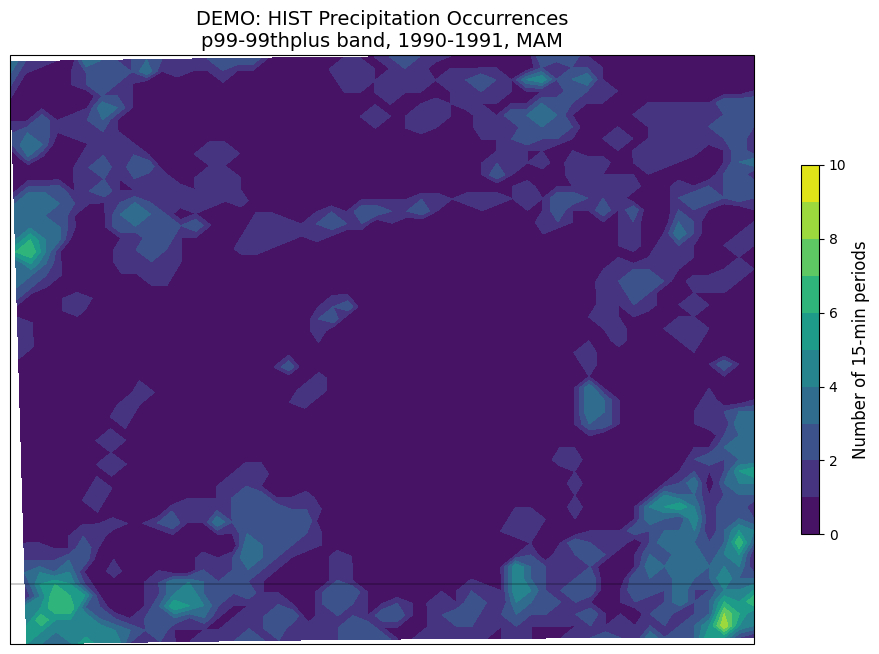

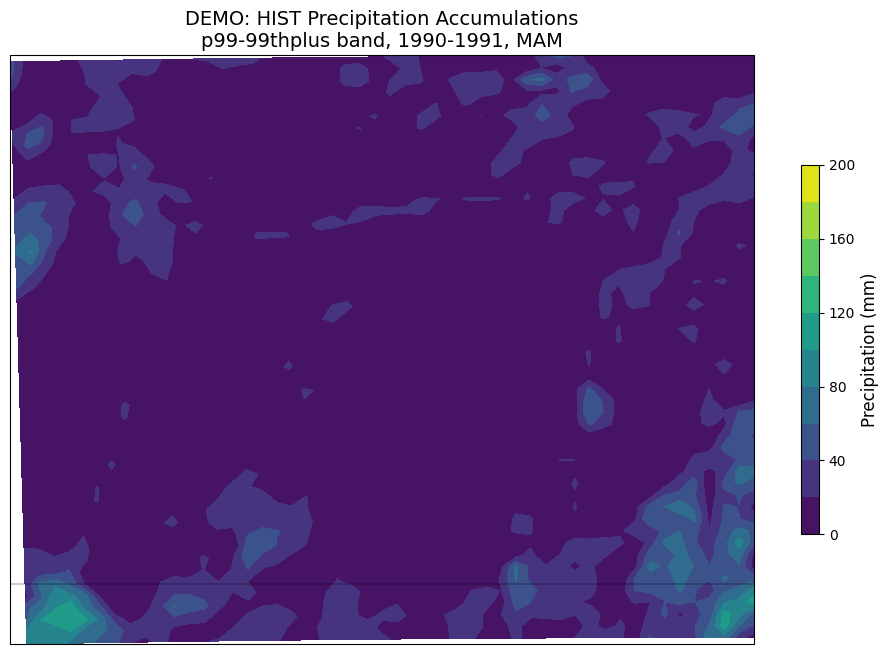

In [10]:
# Demo Visualization data spot-check
visualize_band_results(
    year=1990,  #hydroyear
    band_desc="p99-99thplus",
    var_type='both',
    season_months=[3,4,5]  # Spring
)